In [18]:
"""
Lassoo Regularization (L1)
This is a regularization technique used in feature selection 
using a shrinkage method also referred to as the penalized regression Method.
Lasso : Shrinks coefficients toward zero but does not make them exactly zero.
cost function = loss + penalty(lanba)slope of curve(summanization)

MSE = 1/n(summization(y-y')^2)  + lamba*weightage

Ridge Regularization (L2)
It is an extension to linear Regression that introduces a regularization term to reduce model complexity and help prevent overfiting.
It working value/ magnitude of coefficient is exactly zero
cost function = loss + penalty(slope)^2

Both 
- Feature Selection 
- Prevent Overfitting
"""

"\nLassoo Regularization (L1)\nThis is a regularization technique used in feature selection \nusing a shrinkage method also referred to as the penalized regression Method.\nLasso : Shrinks coefficients toward zero but does not make them exactly zero.\ncost function = loss + penalty(lanba)slope of curve(summanization)\n\nMSE = 1/n(summization(y-y')^2)  + lamba*weightage\n\nRidge Regularization (L2)\nIt is an extension to linear Regression that introduces a regularization term to reduce model complexity and help prevent overfiting.\nIt working value/ magnitude of coefficient is exactly zero\ncost function = loss + penalty(slope)^2\n\nBoth \n- Feature Selection \n- Prevent Overfitting\n"

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [27]:
dataset = pd.read_csv("houseprice.csv")
dataset.head(3)

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace,Price
0,1.982,1.0,3,2.00,133,0,14.2212
1,1.676,1.5,3,0.38,14,1,13.4865
2,1.694,2.0,3,0.96,15,1,11.8007


In [28]:
dataset.isnull().sum()

Living Area    0
Bathrooms      0
Bedrooms       0
Lot Size       0
Age            0
Fireplace      0
Price          0
dtype: int64

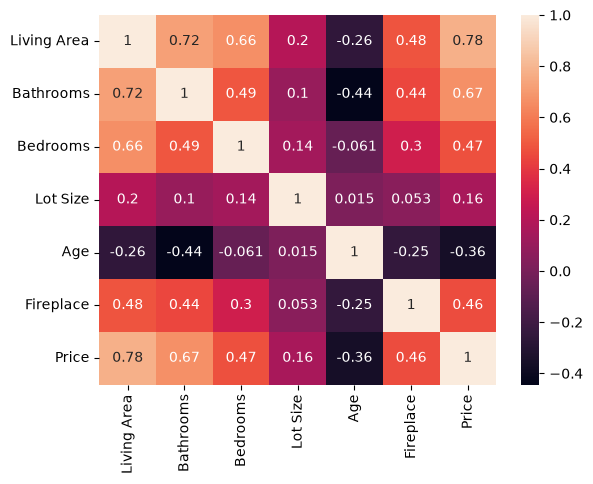

In [29]:
sns.heatmap(dataset.corr(), annot=True)
plt.show()

In [30]:
for col in dataset.columns:
    try:
        pd.to_numeric(dataset[col])
    except:
        print(col)

In [31]:
x = dataset.iloc[:,:-1]
y = dataset["Price"]


In [32]:
from sklearn.metrics import mean_absolute_error , mean_squared_error 
from sklearn.preprocessing import StandardScaler

In [33]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)
x

,Living Area,Bathrooms,Bedrooms,Lot Size,Age,Fireplace
0,0.272473,-1.431707,-0.244539,1.839752,3.008204,-1.207372
1,-0.204791,-0.652197,-0.244539,-0.243830,-0.403080,0.828245
2,-0.176717,0.127313,-0.244539,0.502144,-0.374414,0.828245
3,-0.011390,-1.431707,-1.578038,-0.115214,0.600239,0.828245
4,0.437800,-1.431707,-0.244539,1.633966,0.026914,0.828245
...,...,...,...,...,...,...
1042,-0.008271,0.127313,1.088961,0.515005,0.800903,0.828245
1043,2.232999,2.465842,1.088961,2.482833,-0.775741,0.828245
1044,-0.572877,0.127313,-1.578038,0.051987,1.087565,0.828245
1045,0.347338,0.906822,-0.244539,0.553590,-0.718409,0.828245


In [35]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state = 42)
#random state Hyper parameter tunning for best accuracy

In [37]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge

In [38]:
lr = LinearRegression()
lr.fit(x_train , y_train)
lr.score(x_test , y_test)*100


66.25152995935856

In [39]:
lr.coef_

array([ 4.21709718,  1.25505155, -0.39448864,  0.14306386, -0.60311533,
        0.4044355 ])

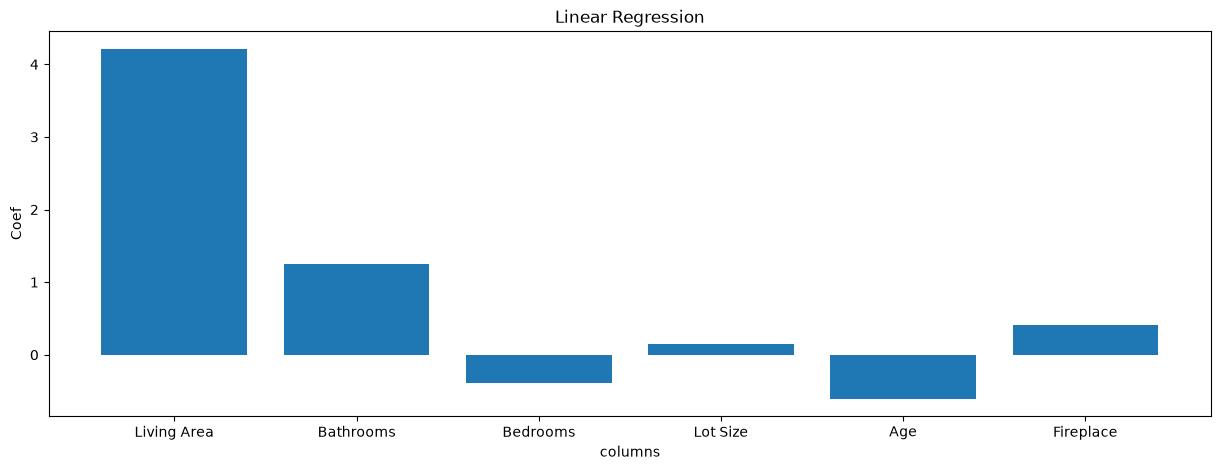

In [40]:
plt.figure(figsize=(15,5))
plt.bar(x.columns,lr.coef_)
plt.title("Linear Regression")
plt.xlabel("columns")
plt.ylabel("Coef")
plt.show()

In [41]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_absolute_error(y_test,lr.predict(x_test))))

15.78561600805452
2.757718203753353
1.6606378906171426


In [42]:
la = Lasso(alpha = 0.5 ) #penalty
la.fit(x_train , y_train)
la.score(x_test,y_test)*100

63.94557672709726

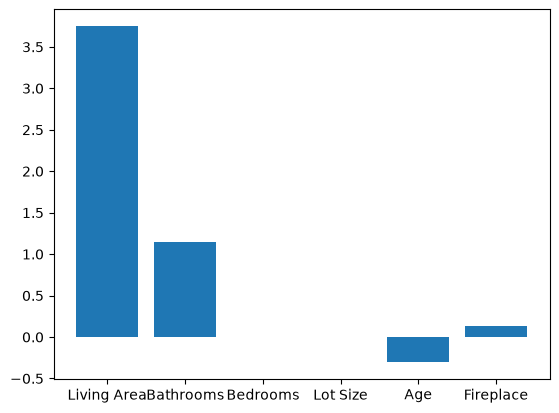

In [43]:
plt.bar(x.columns,la.coef_)
plt.show()

In [52]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_absolute_error(y_test,la.predict(x_test))))

16.864209858773485
2.9039879853855664
1.7041091471456769


In [51]:
ri = Ridge(alpha = 10 ) #penalty
ri.fit(x_train , y_train)
ri.score(x_test,y_test)*100

66.21277858257031

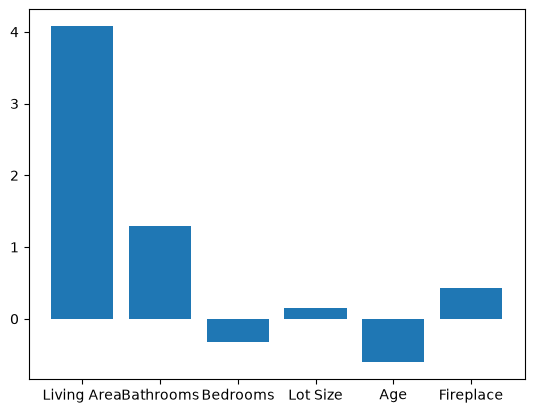

In [45]:
plt.bar(x.columns,ri.coef_)
plt.show()

In [50]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_absolute_error(y_test,ri.predict(x_test))))

15.803741699471827
2.761709812772783
1.6618392860841817


In [48]:
df = pd.DataFrame({"col_name":x.columns , "LinearRegression":lr.coef_ , "Lasso":la.coef_,"Ridge":ri.coef_})

In [49]:
df

,col_name,LinearRegression,Lasso,Ridge
0,Living Area,4.217097,3.750068,4.079135
1,Bathrooms,1.255052,1.149933,1.291286
2,Bedrooms,-0.394489,0.000000,-0.324818
3,Lot Size,0.143064,0.000000,0.153078
4,Age,-0.603115,-0.302809,-0.604011
5,Fireplace,0.404436,0.137931,0.427115
